<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Bhoomi Tulsiyani | 23010101275</b></center>
    
<center><b><h1>Machine Learning - 2301CS621</b></center>

<center><b><h1>Lab - 4</b></center>    
<pre>    

## Simple Linear Regression

## Step 1. Import the necessary libraries

In [1]:
import pandas as pd

## Step 2. Import the dataset

In [3]:
df = pd.read_csv('50_Startups.csv')
df

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


## Step 3 . Check the State Column

In [5]:
df['State'].value_counts()

State
New York      17
California    17
Florida       16
Name: count, dtype: int64

## Step 4 . Splitting dataset in to input and output

In [7]:
X = df.drop(['Profit'], axis=1)

In [9]:
Y = df['Profit']

In [11]:
X

,R&D Spend,Administration,Marketing Spend,State
0,165349.20,136897.80,471784.10,New York
1,162597.70,151377.59,443898.53,California
2,153441.51,101145.55,407934.54,Florida
3,144372.41,118671.85,383199.62,New York
4,142107.34,91391.77,366168.42,Florida
5,131876.90,99814.71,362861.36,New York
6,134615.46,147198.87,127716.82,California
7,130298.13,145530.06,323876.68,Florida
8,120542.52,148718.95,311613.29,New York
9,123334.88,108679.17,304981.62,California


## Step 5 . Convert state Column into Numeric Column

## Step 5.1 .  Perform Transformation

In [13]:
x1 = pd.get_dummies(X, columns = ['State'], drop_first = True)

In [15]:
x1

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
0,165349.20,136897.80,471784.10,False,True
1,162597.70,151377.59,443898.53,False,False
2,153441.51,101145.55,407934.54,True,False
3,144372.41,118671.85,383199.62,False,True
4,142107.34,91391.77,366168.42,True,False
5,131876.90,99814.71,362861.36,False,True
6,134615.46,147198.87,127716.82,False,False
7,130298.13,145530.06,323876.68,True,False
8,120542.52,148718.95,311613.29,False,True
9,123334.88,108679.17,304981.62,False,False


## Step 6 . Dummy variable trap

In [17]:
# Already Performed using | drop_first =True

## Step 7 Splitting dataset in to Train and Test

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x1, Y, train_size=0.8)

## Step 8  Import LinearRegression model from linear_model family 

In [19]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

## Step 9  Fit the data

In [21]:
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Step 10  Predict the data

In [23]:
y_predict = lr.predict(X_test)

## Step 11  Display Result

In [22]:
# y_test and y_predict

In [27]:
y_test

35     96479.51
6     156122.51
9     149759.96
13    134307.35
38     81229.06
17    125370.37
8     152211.77
18    124266.90
15    129917.04
2     191050.39
Name: Profit, dtype: float64

In [29]:
y_predict

array([ 88862.32573846, 161013.09184853, 155534.67801909, 128337.04630688,
        67071.28068171, 130747.80534325, 152846.67839082, 128694.97139409,
       146844.46813045, 182351.3891416 ])

In [31]:
import matplotlib.pyplot as plt

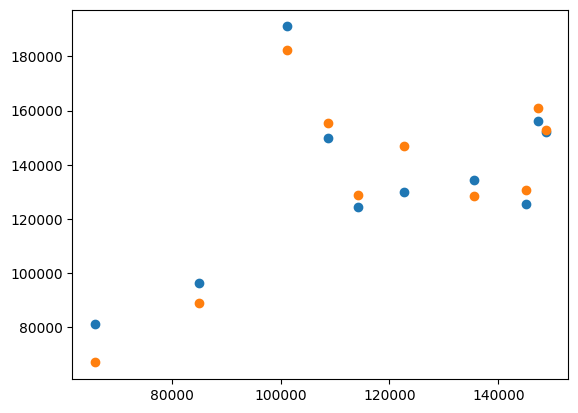

In [35]:
plt.scatter(X_test['Administration'], y_test)
plt.scatter(X_test['Administration'], y_predict)

## RSS

In [37]:
import numpy as np

In [39]:
np.sum((y_test.values - y_predict) ** 2)

762512071.3575693

In [41]:
len(y_test)

10

In [43]:
from sklearn.metrics import mean_squared_error

In [45]:
mean_squared_error(y_test.values, y_predict) * len(y_test)

762512071.3575695

In [47]:
len(y_predict)

10

## R Square

In [49]:
from sklearn.metrics import r2_score

In [51]:
r2_score(y_test, y_predict)

0.912381867388972

## Now use Polynomial Regression on Position_Salaries dataset

In [55]:
df = pd.read_csv('Position_Salaries.csv')
df

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


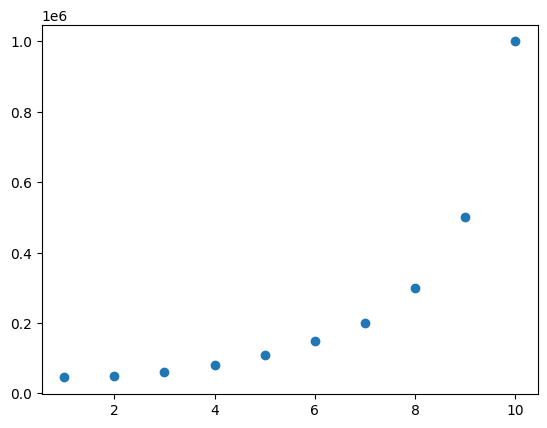

In [57]:
plt.scatter(df['Level'], df['Salary'])

In [89]:
x = df.iloc[::,1:2:]
y = df['Salary']

In [91]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 7)
X_train

,Level
2,3
1,2
9,10
7,8
3,4
6,7
4,5


In [93]:
from sklearn.preprocessing import PolynomialFeatures

In [95]:
poly = PolynomialFeatures(degree = 2)

In [99]:
x1 = poly.fit_transform(X_train)
x1

array([[  1.,   3.,   9.],
       [  1.,   2.,   4.],
       [  1.,  10., 100.],
       [  1.,   8.,  64.],
       [  1.,   4.,  16.],
       [  1.,   7.,  49.],
       [  1.,   5.,  25.]])

In [101]:
lr = LinearRegression()

In [103]:
lr.fit(x1, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [113]:
y_poly_predict = lr.predict(poly.fit_transform(X_test))
y_poly_predict

array([649837.66233766, 113068.18181818, 248647.18614719])

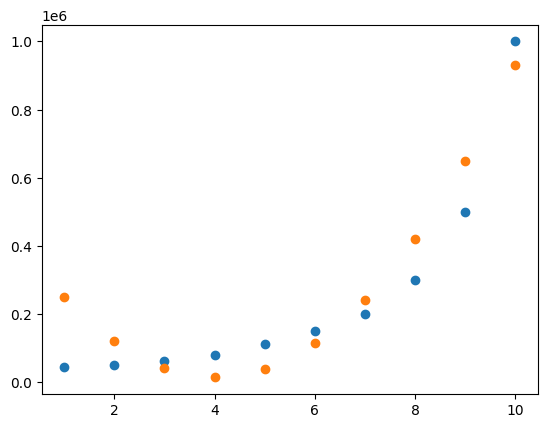

In [119]:
plt.scatter(df['Level'], df['Salary'])
plt.scatter(df['Level'], lr.predict(poly.fit_transform(x)))